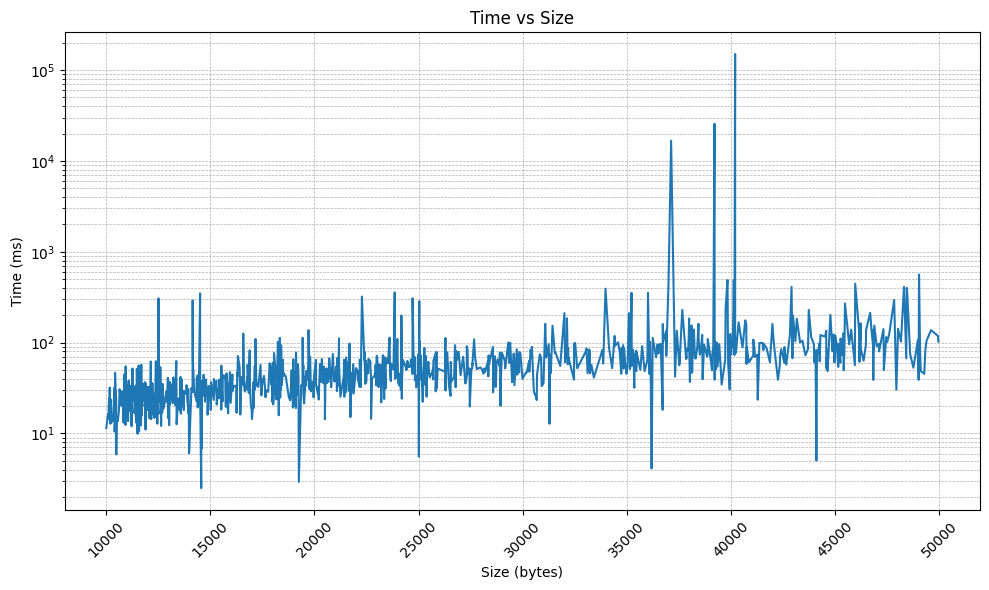

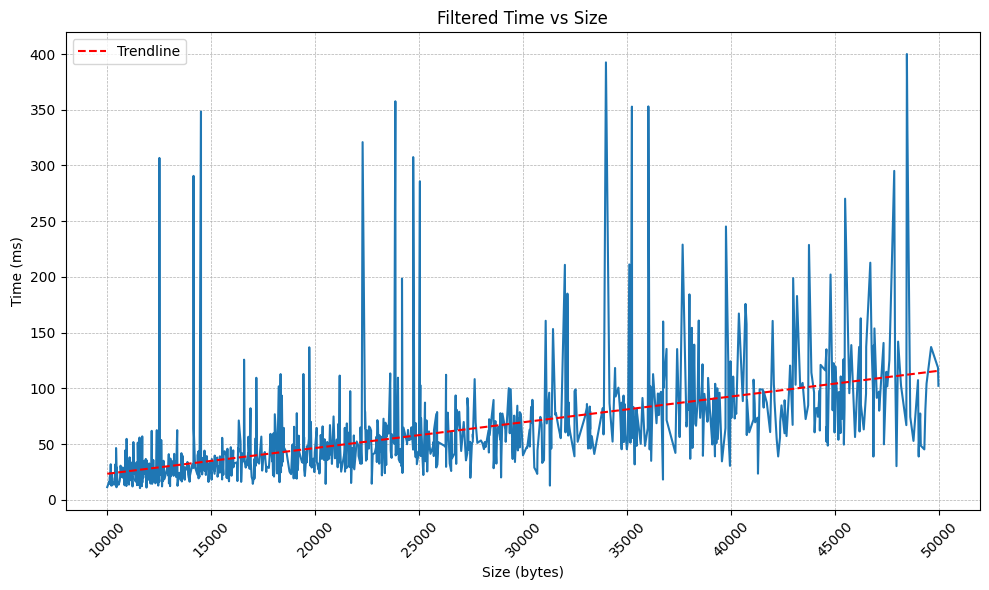

In [ ]:
# ruff: noqa: T201, FBT003


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


data = pd.read_csv("data.csv")
data = data.sort_values(by="size")

plt.figure(figsize=(10, 6))
plt.plot(data["size"], data["time"], linestyle="-")
plt.yscale("log")
plt.xlabel("Size (bytes)")
plt.ylabel("Time (ms)")
plt.title("Time vs Size")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

lower_bound = data["time"].quantile(0.01)
upper_bound = data["time"].quantile(0.99)
filtered_data = data[
    (data["time"] >= lower_bound) & (data["time"] <= upper_bound)
]
plt.figure(figsize=(10, 6))
plt.plot(filtered_data["size"], filtered_data["time"], linestyle="-")
plt.xlabel("Size (bytes)")
plt.ylabel("Time (ms)")
plt.title("Filtered Time vs Size")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
# add trendline
z = np.polyfit(filtered_data["size"], filtered_data["time"], 1)
p = np.poly1d(z)
plt.plot(
    filtered_data["size"],
    p(filtered_data["size"]),
    color="red",
    linestyle="--",
    label="Trendline",
)
plt.legend()
plt.show()